# Bài tập mẫu
Nhận dạng chữ viết tay

Train shape: (19999, 785)
Test shape: (9999, 785)
X_train: (19999, 784)
y_train: (19999,)
X_test : (9999, 784)
y_test : (9999,)
New X_train shape: (19999, 28, 28, 1)
New X_test shape : (9999, 28, 28, 1)
Classes: [0 1 2 3 4 5 6 7 8 9]


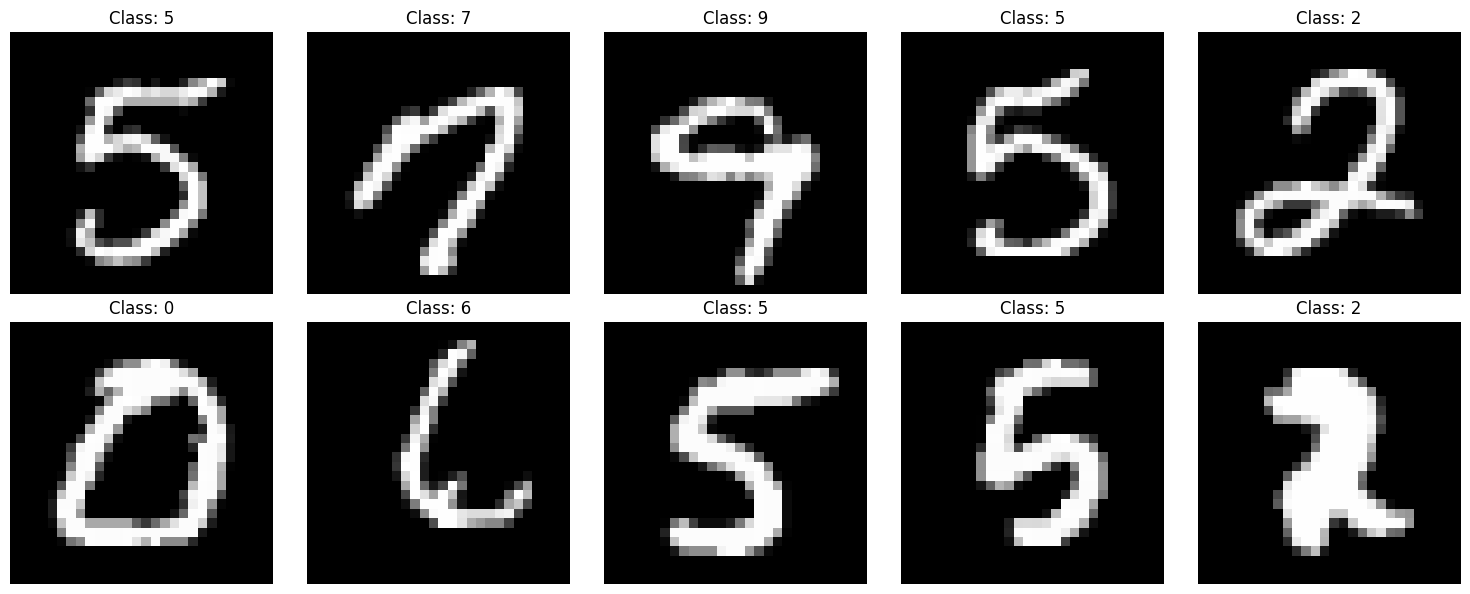

y_train shape: (19999, 10)
y_test shape : (9999, 10)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.8222 - loss: 0.6308 - val_accuracy: 0.9410 - val_loss: 0.2138
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9529 - loss: 0.1577 - val_accuracy: 0.9590 - val_loss: 0.1336
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.9687 - loss: 0.1059 - val_accuracy: 0.9655 - val_loss: 0.1169
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9769 - loss: 0.0811 - val_accuracy: 0.9665 - val_loss: 0.1065
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.9802 - loss: 0.0664 - val_accuracy: 0.9780 - val_loss: 0.0787
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9827 - loss: 0.0559 - val_accuracy: 0.9785 - val_loss: 0.0794
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9844 - loss: 0.0490 - val_accuracy: 0.9815 - val_loss: 0.0701
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9865 - loss: 0.0419 - 

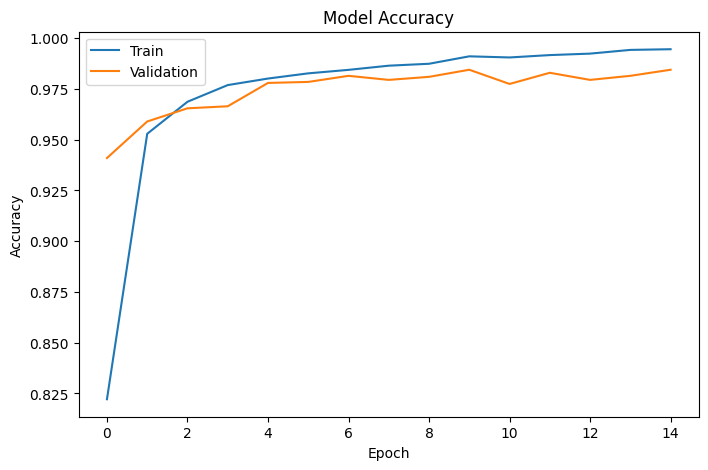

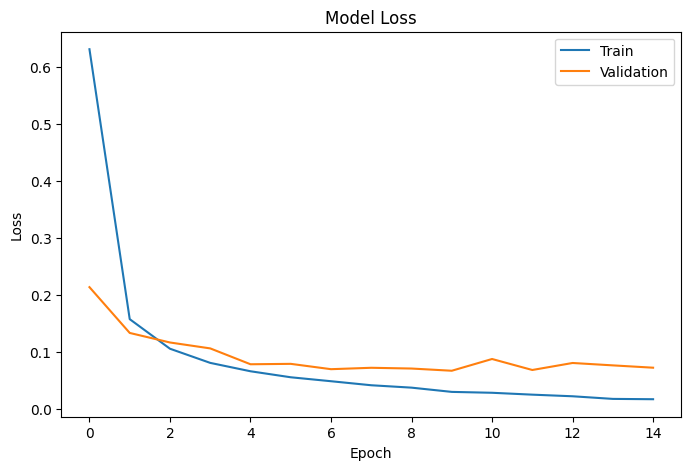

Test Loss     : 0.05531395971775055
Test Accuracy : 0.9844984412193298
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted: 1
Actual   : 1


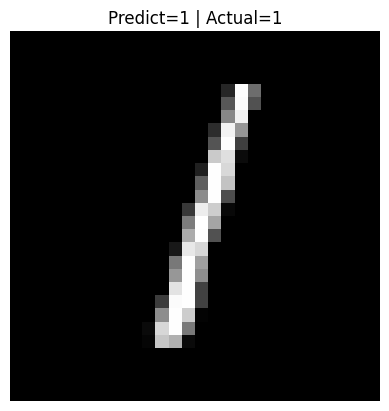

Model saved!


In [ ]:
# =====================================
# CNN NHẬN DẠNG CHỮ SỐ VIẾT TAY MNIST
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# =====================================
# 1. ĐỌC DỮ LIỆU
# =====================================

mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

# =====================================
# 2. TIỀN XỬ LÝ DỮ LIỆU
# =====================================

num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa pixel về [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Chuyển sang numpy
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

# Reshape thành ảnh 28x28x1
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("New X_train shape:", X_train.shape)
print("New X_test shape :", X_test.shape)

print("Classes:", np.unique(y_train))

# =====================================
# 3. HIỂN THỊ 10 ẢNH ĐẦU TIÊN
# =====================================

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Class: {y_train.iloc[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# =====================================
# 4. ONE-HOT ENCODING
# =====================================

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# =====================================
# 5. XÂY DỰNG CNN
# =====================================

model = Sequential()

model.add(Input(shape=input_shape))

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)

model.add(Flatten())

model.add(
    Dense(
        units=10,
        activation='softmax'
    )
)

model.summary()

# =====================================
# 6. HUẤN LUYỆN
# =====================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

# =====================================
# 7. VẼ ACCURACY
# =====================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# =====================================
# 8. VẼ LOSS
# =====================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# =====================================
# 9. ĐÁNH GIÁ TRÊN TẬP TEST
# =====================================

score = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss     :", score[0])
print("Test Accuracy :", score[1])

# =====================================
# 10. DỰ ĐOÁN 1 ẢNH
# =====================================

index = 1

predict = model.predict(X_test[index:index+1])

predicted_class = np.argmax(predict)
true_class = np.argmax(y_test[index])

print("Predicted:", predicted_class)
print("Actual   :", true_class)

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predict={predicted_class} | Actual={true_class}")
plt.axis('off')
plt.show()

# =====================================
# 11. LƯU MODEL
# =====================================

model.save("cnn_mnist.keras")

print("Model saved!")

In [ ]:
from PIL import Image, ImageOps

def preprocess_digit(image_path):
    img = Image.open(image_path)

    # grayscale
    img = img.convert('L')

    # đảo màu thành nền đen chữ trắng
    img = ImageOps.invert(img)

    # resize
    img = img.resize((28, 28))

    img = np.array(img)

    # normalize
    img = img.astype('float32') / 255.0

    return img.reshape(1, 28, 28, 1)

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = preprocess_digit(filename)

pred = model.predict(img)

print("Predicted digit:", np.argmax(pred))
print("Probability:", np.max(pred))

Saving so3_2.png to so3_2 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted digit: 3
Probability: 0.46508098


# Bài 1. Nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau
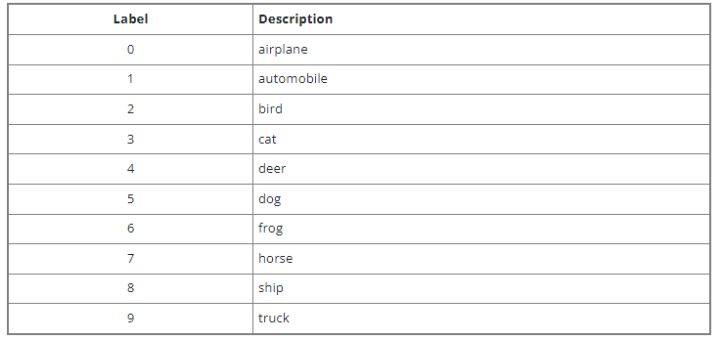

In [ ]:
# Import thư viện
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

In [ ]:
# Load CIFAR10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


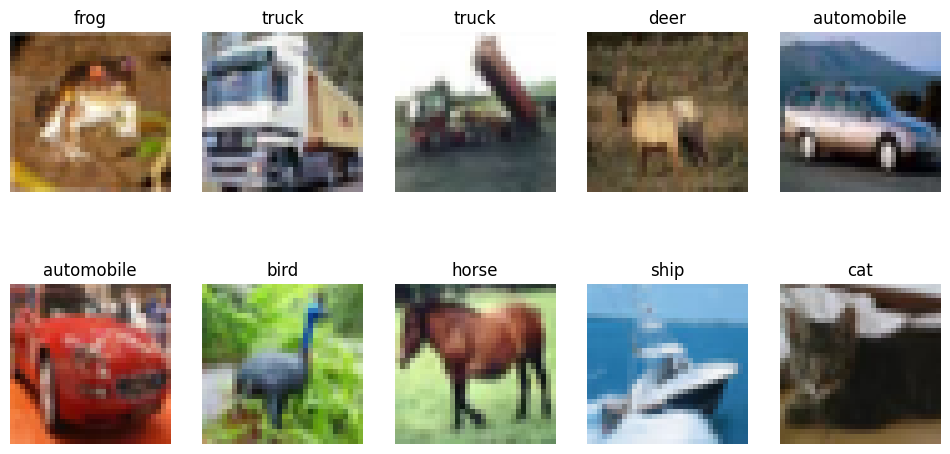

In [ ]:
# Hiển thị một số ảnh
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [ ]:
#Tiền xử lý dữ liệu
# chuẩn hóa pixel
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
# One-hot coding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)


(50000, 10)
(10000, 10)


In [ ]:
# Xây dựng CNN
model = Sequential()

# Block 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,746 (8.27 MB)

 Trainable params: 2,168,554 (8.27 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Huấn luyện
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 307s 858ms/step - accuracy: 0.3378 - loss: 1.8791 - val_accuracy: 0.2210 - val_loss: 2.3033
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 300s 795ms/step - accuracy: 0.4743 - loss: 1.4248 - val_accuracy: 0.5778 - val_loss: 1.2013
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 277s 788ms/step - accuracy: 0.5463 - loss: 1.2580 - val_accuracy: 0.6114 - val_loss: 1.0925
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 324s 793ms/step - accuracy: 0.5850 - loss: 1.1558 - val_accuracy: 0.6792 - val_loss: 0.9162
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 277s 786ms/step - accuracy: 0.6240 - loss: 1.0586 - val_accuracy: 0.6866 - val_loss: 0.9069
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 277s 786ms/step - accuracy: 0.6542 - loss: 0.9876 - val_accuracy: 0.7054 - val_loss: 0.8471
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 322s 787ms/step - accuracy: 0.6752 - loss: 0.9229 - val_accuracy: 0.7316 - val_loss: 0.7744
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 279s 793ms/step - accuracy: 0.6941 -

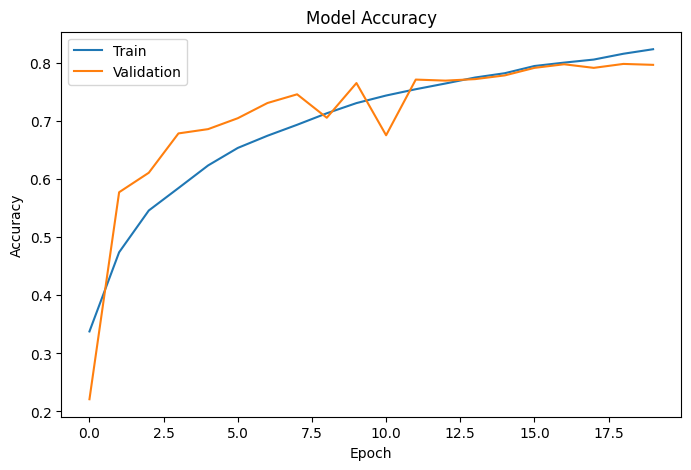

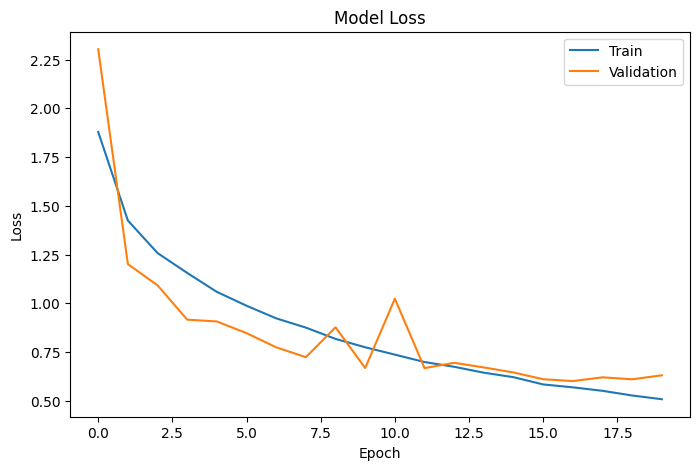

In [ ]:
# Vẽ accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()
# Vẽ loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
# Đánh giá trên tập test
score = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

Test Loss: 0.6526150107383728
Test Accuracy: 0.7893000245094299


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


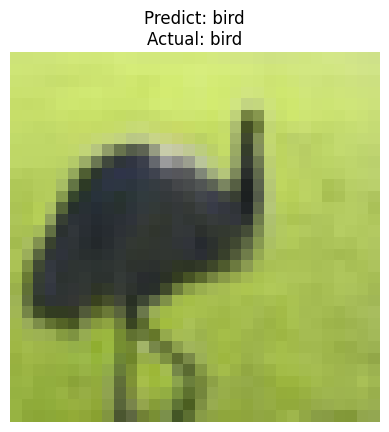

In [ ]:
# Dự đoán bất kỳ trong tập test
idx = 123

image = X_test[idx]

prediction = model.predict(
    image.reshape(1,32,32,3)
)

predicted_class = np.argmax(prediction)

actual_class = np.argmax(y_test[idx])

plt.imshow(image)

plt.title(
    f'Predict: {class_names[predicted_class]}\n'
    f'Actual: {class_names[actual_class]}'
)

plt.axis('off')
plt.show()

In [ ]:
# Lưu model
model.save('cifar10_cnn.keras')

# Bài 2: Nhận dạng ảnh Cat và Dog bằng CNN

In [ ]:
# import dữ liệu
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Kết nối Dataset
from google.colab import drive
drive.mount('/content/drive')
train_path = "/content/drive/MyDrive/cats_and_dogs/training_set"
test_path  = "/content/drive/MyDrive/cats_and_dogs/test_set"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cats train: 4001
Dogs train: 3254
Cats test: 1012
Dogs test: 1013


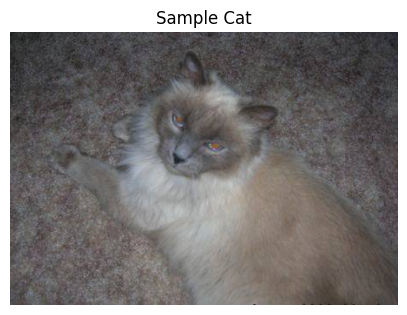

In [ ]:
# Đọc dữ liệu
# Đếm số lượng ảnh
print("Cats train:",
      len(os.listdir(train_path + "/cats")))

print("Dogs train:",
      len(os.listdir(train_path + "/dogs")))

print("Cats test:",
      len(os.listdir(test_path + "/cats")))

print("Dogs test:",
      len(os.listdir(test_path + "/dogs")))
# Hiển thị ảnh mẫu
cat_folder = train_path + "/cats"

sample_img = os.listdir(cat_folder)[0]

img = Image.open(
    os.path.join(cat_folder, sample_img)
)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Sample Cat")
plt.axis("off")
plt.show()

In [ ]:
# Xử lý dữ liệu
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)
print(train_generator.class_indices)

Found 7254 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [ ]:
# Xây dựng mô hình
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Flatten
model.add(Flatten())

# Fully Connected
model.add(Dense(
    units=128,
    activation='relu'
))

model.add(Dropout(0.5))

# Output
model.add(Dense(
    units=1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile và xem kiến trúc model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện và đánh giá mô hình
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)
loss, accuracy = model.evaluate(
    test_generator
)

print("Loss =", loss)
print("Accuracy =", accuracy)

Epoch 1/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 1424s 6s/step - accuracy: 0.5593 - loss: 0.6837 - val_accuracy: 0.5517 - val_loss: 0.6770
Epoch 2/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.6184 - loss: 0.6560 - val_accuracy: 0.6530 - val_loss: 0.6229
Epoch 3/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6691 - loss: 0.6205 - val_accuracy: 0.7148 - val_loss: 0.5671
Epoch 4/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.7128 - loss: 0.5692 - val_accuracy: 0.7380 - val_loss: 0.5250
Epoch 5/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.7328 - loss: 0.5278 - val_accuracy: 0.7731 - val_loss: 0.4956
Epoch 6/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.7532 - loss: 0.4990 - val_accuracy: 0.7830 - val_loss: 0.4682
Epoch 7/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.7781 - loss: 0.4700 - val_accuracy: 0.7830 - val_loss: 0.4686
Epoch 8/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.7823 - loss: 0.4614 - val_acc

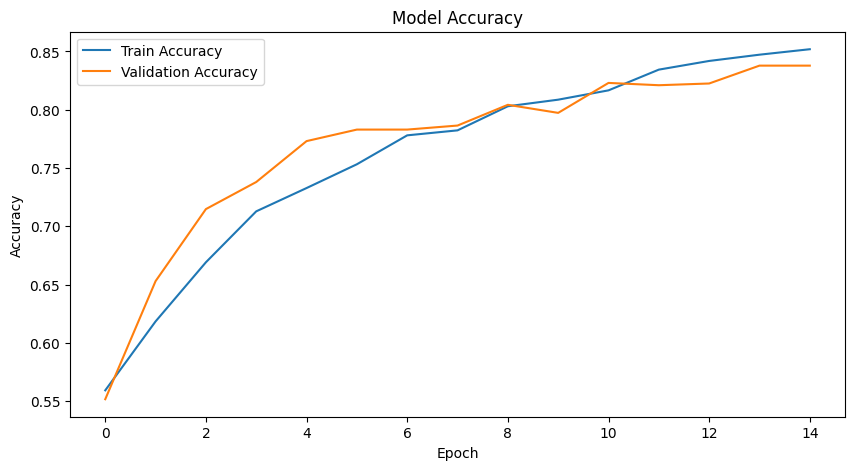

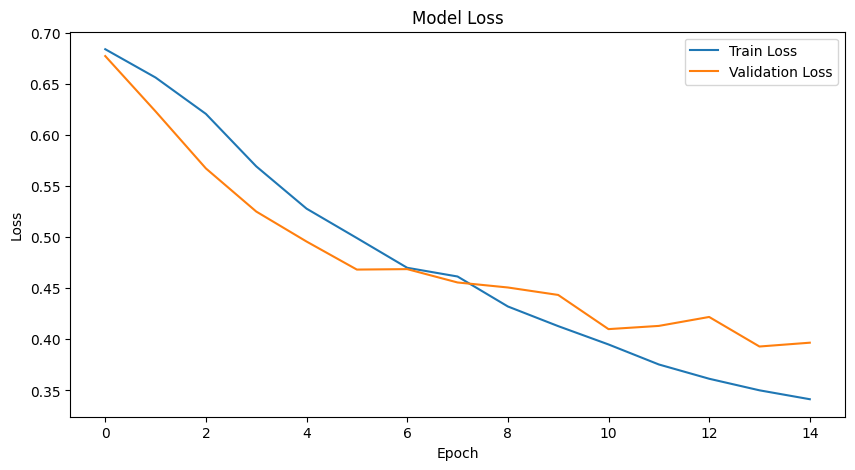

In [ ]:
# Accuracy
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
# Loss
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
# Lưu model
model.save("cat_dog_cnn.h5")

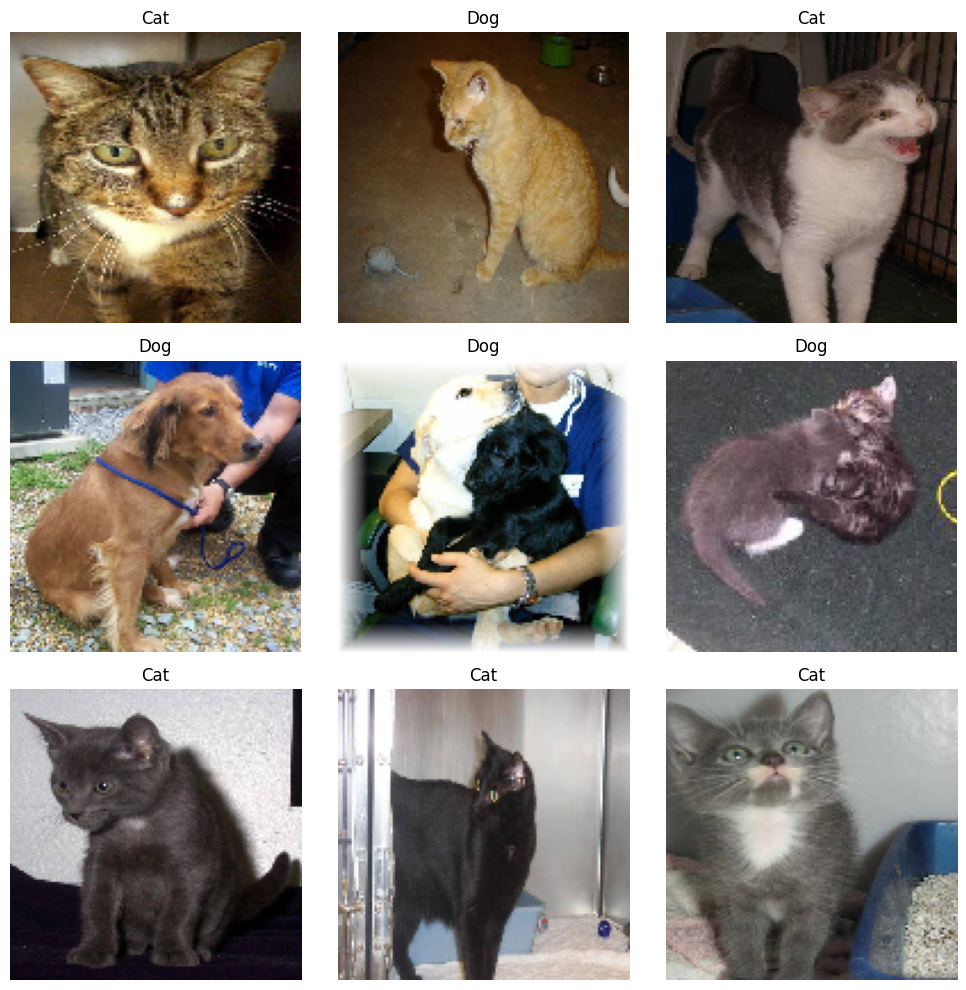

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random
import os

fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax in axes.flat:

    label = random.choice(["cats","dogs"])

    img_name = random.choice(
        os.listdir(os.path.join(test_path, label))
    )

    img_path = os.path.join(
        test_path,
        label,
        img_name
    )

    img = image.load_img(
        img_path,
        target_size=(128,128)
    )

    x = image.img_to_array(img)/255.0
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x, verbose=0)[0][0]

    predict_label = "Dog" if pred > 0.5 else "Cat"

    ax.imshow(img)
    ax.set_title(predict_label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Dự đoán với ảnh bên ngoài
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# 1. Tải lại mô hình đã huấn luyện
try:
    model_cat_dog = load_model('cat_dog_cnn.h5')
    print("Mô hình 'cat_dog_cnn.h5' đã được tải thành công!")
except Exception as e:
    print(f"Không thể tải mô hình: {e}. Hãy đảm bảo bạn đã chạy cell lưu mô hình ('model.save(\'cat_dog_cnn.h5\')') trước đó.")

Mô hình 'cat_dog_cnn.h5' đã được tải thành công!


In [ ]:
# Hàm tiền xử lý ảnh cho mô hình Cat/Dog
def preprocess_image_for_prediction(image_path):
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Chuẩn hóa pixel về [0, 1]
    img_array = np.expand_dims(img_array, axis=0) # Thêm chiều batch
    return img_array, img # Trả về cả ảnh gốc để hiển thị

# 2. Tải ảnh từ máy tính của bạn
uploaded = files.upload()

# Lấy tên file ảnh đã tải lên
filename = list(uploaded.keys())[0]

print(f"Đã tải lên file: {filename}")

Saving con-meo-xau-nhat-the-gioi.jpg to con-meo-xau-nhat-the-gioi.jpg
Đã tải lên file: con-meo-xau-nhat-the-gioi.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Ảnh được dự đoán là: Cat (Xác suất: 0.3573)


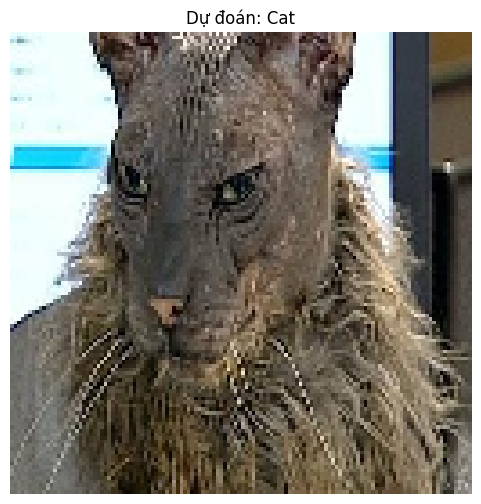

In [ ]:
# 3. Tiền xử lý ảnh và 4. Dự đoán, hiển thị kết quả
if 'model_cat_dog' in locals(): # Kiểm tra xem mô hình đã được tải chưa
    processed_img_array, original_img = preprocess_image_for_prediction(filename)

    # Dự đoán
    prediction = model_cat_dog.predict(processed_img_array)

    # Kết quả dự đoán (sigmoid output)
    predicted_probability = prediction[0][0]

    if predicted_probability > 0.5:
        predicted_label = "Dog"
    else:
        predicted_label = "Cat"

    print(f"Ảnh được dự đoán là: {predicted_label} (Xác suất: {predicted_probability:.4f})")

    # Hiển thị ảnh và kết quả dự đoán
    plt.figure(figsize=(6, 6))
    plt.imshow(original_img)
    plt.title(f"Dự đoán: {predicted_label}")
    plt.axis('off')
    plt.show()
else:
    print("Mô hình chưa được tải. Vui lòng chạy cell tải mô hình trước.")